# Exploratory Data Analysis — `dataset/dataset.csv`

This notebook is a **fully independent** EDA pass over the cleaned, aggregated transaction
log produced by `notebook/merge_and_aggregate.ipynb` (`merge_dataset.py` + `aggregate_dataset.py`
&rarr; `dataset/dataset.csv`). It does not modify, replace, or depend on
`notebook/data-processing.ipynb` — some duplication of basic checks (missing values, unique
counts, etc.) between the two notebooks is expected and accepted.

## Business context

The goal is demand forecasting for every item at every outlet, horizon &le; 4 days. The central
SCM team currently ships to **Region 1** outlets every **Monday & Thursday**, and to **Region 2**
outlets every **Tuesday & Friday** — so the eventual model needs to predict *cumulative* demand
over the lead-time window until the next shipment (a 3-day or 4-day window, depending on region
and shipment day).

**Important constraint:** as of this notebook, there is no Region 1 / Region 2 (or any
delivery-schedule) mapping anywhere in the data (`dataset/outlets.csv` only has
`Kecamatan`/`Kota`). This notebook does **not** guess at or invent that mapping — the
day-of-week and lead-time-window analyses below are deliberately generic/non-region-segmented
proxies. The gap itself is called out explicitly in the final "Open Questions / Data Gaps"
section.

## Executive Summary

See **§9 Conclusion & Pre-Modeling Verification Checklist** at the end of this notebook for
the full one-line-per-finding summary, including what still needs data-owner verification
before modeling.

## 1. Setup

In [5]:
import sys
import os

# Add the parent directory to the system path
sys.path.append(os.path.abspath('..'))

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils.data_preprocessing import build_panel
from utils.data_preprocessing import calendar_features
from utils.data_preprocessing import outlet_features

%matplotlib inline

In [7]:
# Palette: one sequential blue for single-series magnitude/ranking charts, a small
# categorical set for genuine multi-series identity (<=8 series), and a diverging
# colormap reserved for the one true polarity chart (branch x day-of-week deviation).
BLUE = "#2a78d6"
BLUE_DARK = "#173f73"
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#7a5195", "#ef5675", "#665191", "#003f5c"]
DIVERGING_CMAP = "RdBu_r"

plt.rcParams.update({
    "figure.dpi": 100,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#dddddd",
    "grid.linewidth": 0.6,
    "font.size": 10,
})

In [8]:
DATA_PATH = "../dataset/csv/dataset.csv"

dtype_map = {
    "Kategori Barang": "category",
    "Kode Barang": str,
    "Nama Barang": str,
    "Nama Cabang": "category",
    "Satuan": "category",
    "Kuantitas": "float64",
}

df = pd.read_csv(DATA_PATH, sep=";", encoding="utf-8-sig", dtype=dtype_map)
df["Tanggal"] = pd.to_datetime(df["Tanggal"], format="%d %b %Y")

print(f"shape: {df.shape}")
df.head()

shape: (693563, 7)


,Tanggal,Kategori Barang,Kode Barang,Nama Barang,Nama Cabang,Satuan,Kuantitas
0,2024-01-01,Barang Semi FG (WIP-2),FGS-00001,Ayam Kebuli (0.9),KY001 - Kebuli Yaman Kutabumi (Pusat),Potong,235.0
1,2024-01-01,Barang Semi FG (WIP-2),FGS-00002,Kambing Kebuli,KY001 - Kebuli Yaman Kutabumi (Pusat),Porsi,3.0
2,2024-01-01,Barang Semi FG (WIP-2),FGS-00003,Iga Sapi Kebuli,KY001 - Kebuli Yaman Kutabumi (Pusat),Porsi,7.0
3,2024-01-01,Barang Semi FG (WIP-2),FGS-00004,Nasi Kebuli,KY001 - Kebuli Yaman Kutabumi (Pusat),Porsi,256.0
4,2024-01-01,Barang Semi FG (WIP-2),FGS-00005,Sambal - FG,KY001 - Kebuli Yaman Kutabumi (Pusat),Porsi,263.0


## 2. Data Health Check

Shape, dtypes, missing values, duplicate checks, and categorical structure.

In [9]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 693563 entries, 0 to 693562
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Tanggal          693563 non-null  datetime64[ns]
 1   Kategori Barang  693563 non-null  category      
 2   Kode Barang      693563 non-null  object        
 3   Nama Barang      693563 non-null  object        
 4   Nama Cabang      693563 non-null  category      
 5   Satuan           693563 non-null  category      
 6   Kuantitas        693563 non-null  float64       
dtypes: category(3), datetime64[ns](1), float64(1), object(2)
memory usage: 105.9 MB


In [10]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(3)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
display(missing_summary)

,missing_count,missing_pct
Tanggal,0,0.0
Kategori Barang,0,0.0
Kode Barang,0,0.0
Nama Barang,0,0.0
Nama Cabang,0,0.0
Satuan,0,0.0
Kuantitas,0,0.0


In [11]:
exact_dupes = df.duplicated().sum()
print(f"Exact duplicate rows: {exact_dupes}")

business_key = ["Tanggal", "Kategori Barang", "Kode Barang", "Nama Barang", "Nama Cabang", "Satuan"]
business_key_dupes = df.duplicated(subset=business_key).sum()
print(f"Business-key duplicate rows (should be 0 post-aggregation): {business_key_dupes}")

Exact duplicate rows: 0
Business-key duplicate rows (should be 0 post-aggregation): 0


In [12]:
categorical_cols = ["Kategori Barang", "Kode Barang", "Nama Barang", "Nama Cabang", "Satuan"]
cardinality = df[categorical_cols].nunique().rename("unique_count")
display(cardinality.to_frame())

,unique_count
Kategori Barang,12
Kode Barang,109
Nama Barang,112
Nama Cabang,67
Satuan,12


### Item consistency: `Satuan` & `Kategori Barang` per SKU

Downstream aggregation assumes each `Kode Barang` has one fixed `Satuan` and one fixed
`Kategori Barang`. Neither has been explicitly verified yet — check both here.

In [13]:
satuan_per_item = df.groupby("Kode Barang")["Satuan"].nunique()
inconsistent_satuan = satuan_per_item[satuan_per_item > 1]
print(f"SKUs with >1 distinct Satuan: {len(inconsistent_satuan)} / {satuan_per_item.shape[0]}")
if len(inconsistent_satuan) > 0:
    display(
        df[df["Kode Barang"].isin(inconsistent_satuan.index)]
        [["Kode Barang", "Nama Barang", "Satuan"]]
        .drop_duplicates()
        .sort_values("Kode Barang")
    )

SKUs with >1 distinct Satuan: 0 / 109


In [14]:
kategori_per_item = df.groupby("Kode Barang")["Kategori Barang"].nunique()
inconsistent_kategori = kategori_per_item[kategori_per_item > 1]
print(f"SKUs with >1 distinct Kategori Barang: {len(inconsistent_kategori)} / {kategori_per_item.shape[0]}")
if len(inconsistent_kategori) > 0:
    display(
        df[df["Kode Barang"].isin(inconsistent_kategori.index)]
        [["Kode Barang", "Nama Barang", "Kategori Barang"]]
        .drop_duplicates()
        .sort_values("Kode Barang")
    )

SKUs with >1 distinct Kategori Barang: 27 / 109


,Kode Barang,Nama Barang,Kategori Barang
0,FGS-00001,Ayam Kebuli (0.9),Barang Semi FG (WIP-2)
42860,FGS-00001,Ayam Kebuli (0.9),Barang Jadi (FG)
1,FGS-00002,Kambing Kebuli,Barang Semi FG (WIP-2)
42862,FGS-00002,Kambing Kebuli,Barang Jadi (FG)
3,FGS-00004,Nasi Kebuli,Barang Semi FG (WIP-2)
42863,FGS-00004,Nasi Kebuli,Barang Jadi (FG)
4,FGS-00005,Sambal - FG,Barang Semi FG (WIP-2)
42864,FGS-00005,Sambal - FG,Barang Jadi (FG)
42840,FGS-00006,Club Mineral 330 ml (Menu pakai kode CM-330),Minuman - FG
277,FGS-00006,Club Mineral 330 ml,Minuman


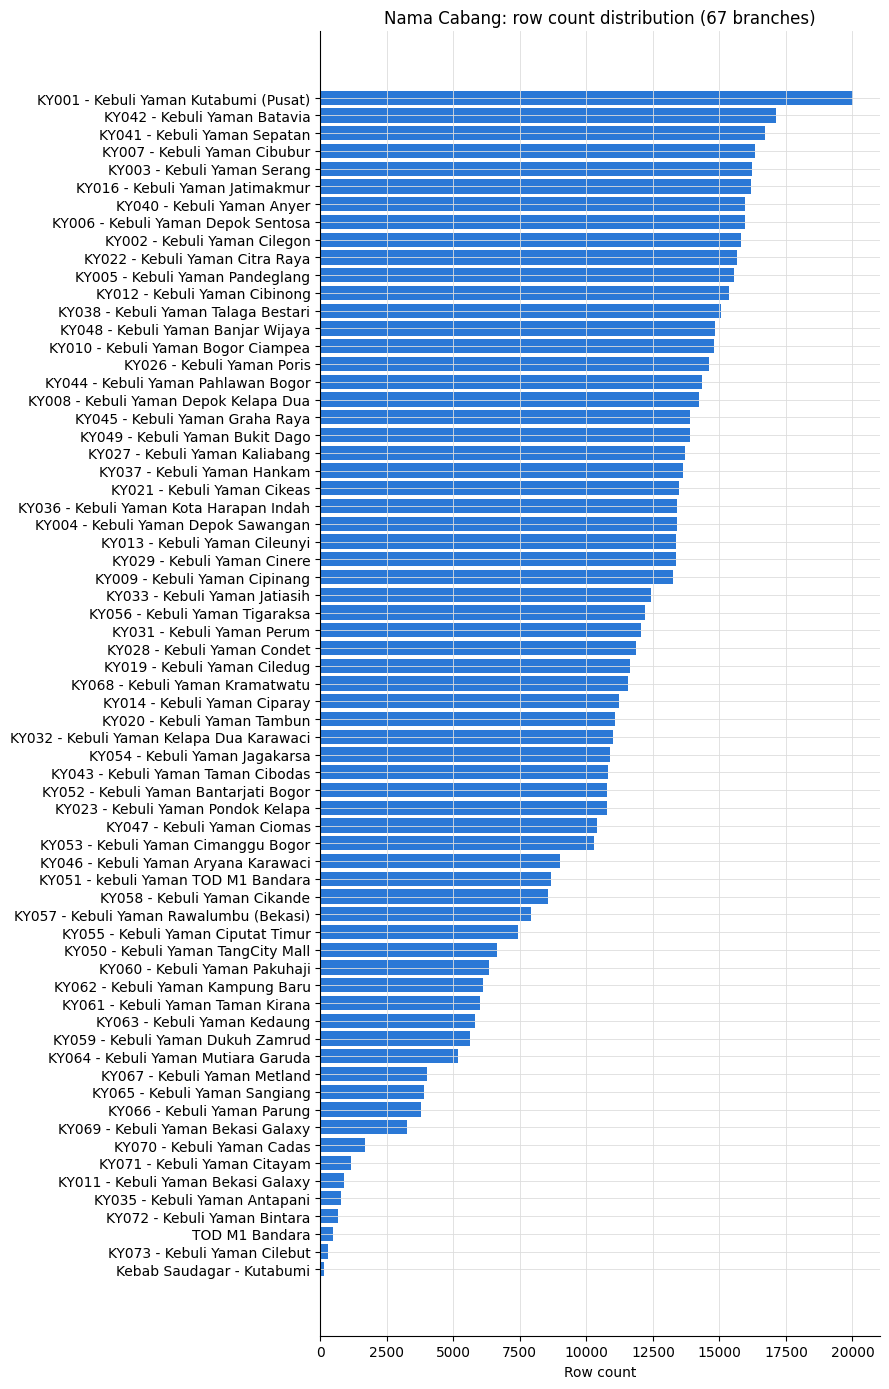

In [15]:
branch_counts = df["Nama Cabang"].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 14))
ax.barh(branch_counts.index, branch_counts.values, color=BLUE)
ax.set_xlabel("Row count")
ax.set_title("Nama Cabang: row count distribution (67 branches)")
plt.tight_layout()
plt.show()

In [16]:
top20_by_rows = df["Nama Barang"].value_counts().head(20)
top20_by_volume = (
    df.groupby("Nama Barang")["Kuantitas"].sum().sort_values(ascending=False).head(20)
)

print("Top 20 SKUs by row (transaction) count:")
display(top20_by_rows.to_frame("row_count"))

print("Top 20 SKUs by total Kuantitas (volume):")
display(top20_by_volume.to_frame("total_kuantitas"))

Top 20 SKUs by row (transaction) count:


,row_count
Nama Barang,
Nasi Kebuli,36730
Sambal - FG,36730
Cup Sambal Take Away,36730
Ayam Kebuli (0.9),36729
Lunch Box,36598
Cup Sambal Dine in,35521
Kambing Kebuli,32839
Cup Sambal Loyang Mini,26495
Box Loyang Mini,26493


Top 20 SKUs by total Kuantitas (volume):


,total_kuantitas
Nama Barang,
Sambal - FG,4311074.0
Nasi Kebuli,4167981.5
Cup Sambal Take Away,3224822.0
Ayam Kebuli (0.9),3202822.5
Lunch Box,2014544.0
Cup Sambal Dine in,1029745.0
Rice Bowl 600 ml,979187.0
Kambing Kebuli,258890.0
AirAlam 330 ml (Menu pakai kode AA),200766.0


## 3. `Kuantitas` Distribution & Outliers

In [17]:
negative_qty = df[df['Kuantitas'] < 0]
print(f"Jumlah baris dengan kuantitas negatif: {len(negative_qty)}")
if len(negative_qty) > 0:
    display(negative_qty.head())


Jumlah baris dengan kuantitas negatif: 0


In [18]:
df["Kuantitas"].describe()

count    693563.000000
mean         30.390492
std          60.997008
min           1.000000
25%           2.000000
50%           5.000000
75%          34.000000
max        5250.000000
Name: Kuantitas, dtype: float64

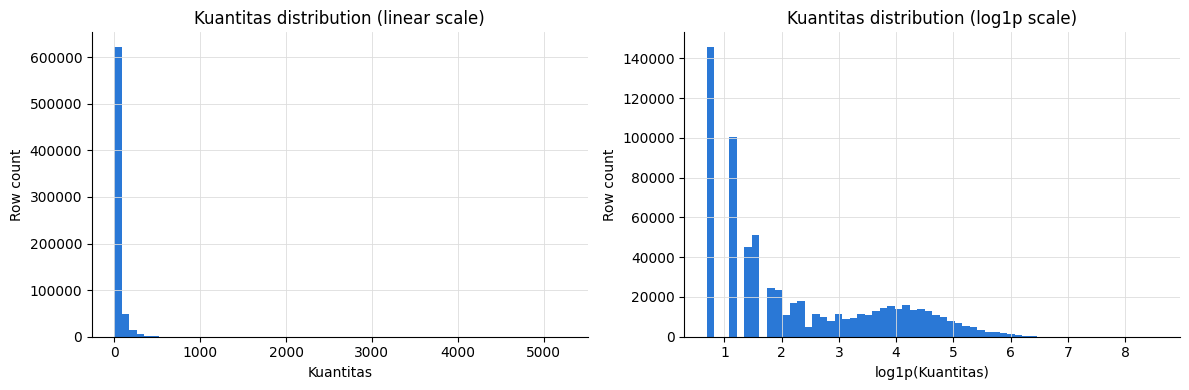

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["Kuantitas"], bins=60, color=BLUE)
axes[0].set_title("Kuantitas distribution (linear scale)")
axes[0].set_xlabel("Kuantitas")
axes[0].set_ylabel("Row count")

axes[1].hist(np.log1p(df["Kuantitas"]), bins=60, color=BLUE)
axes[1].set_title("Kuantitas distribution (log1p scale)")
axes[1].set_xlabel("log1p(Kuantitas)")
axes[1].set_ylabel("Row count")

plt.tight_layout()
plt.show()

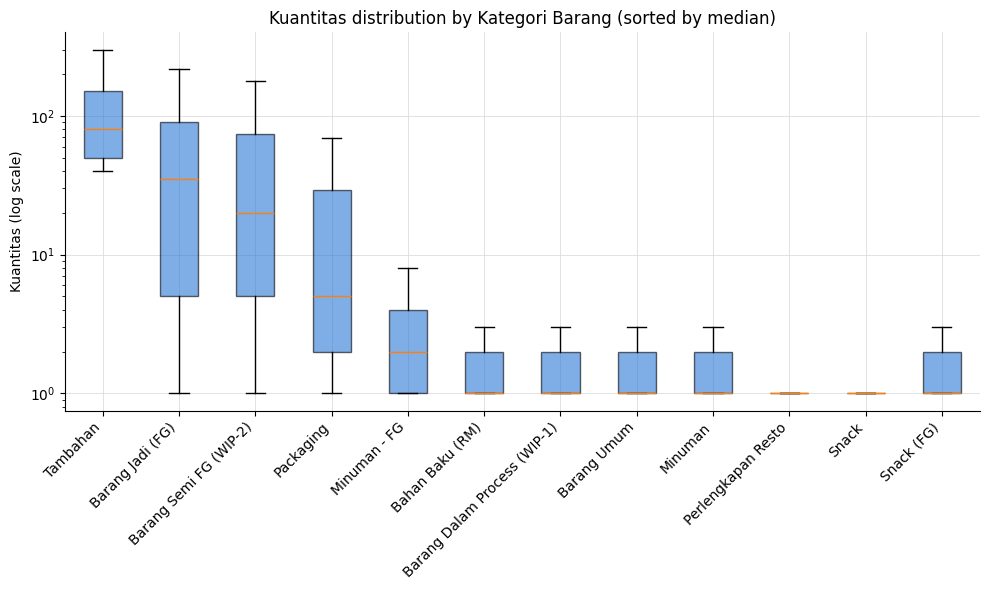

In [20]:
order = (
    df.groupby("Kategori Barang", observed=True)["Kuantitas"]
    .median()
    .sort_values(ascending=False)
    .index
)
data_by_cat = [df.loc[df["Kategori Barang"] == cat, "Kuantitas"] for cat in order]

fig, ax = plt.subplots(figsize=(10, 6))
box = ax.boxplot(data_by_cat, tick_labels=list(order), patch_artist=True, showfliers=False)
for patch in box["boxes"]:
    patch.set_facecolor(BLUE)
    patch.set_alpha(0.6)
ax.set_yscale("log")
ax.set_ylabel("Kuantitas (log scale)")
ax.set_title("Kuantitas distribution by Kategori Barang (sorted by median)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Cara baca:
- Skala y log dipakai karena Kuantitas sangat right-skewed (sama seperti histogram sebelumnya) — kalau linear, box untuk kategori bermedian 1 akan menempel rata di sumbu x dan tidak terbaca.
- showfliers=False — outlier ekstrem (yang sudah kita bahas terpisah, mis. 5250 di Barang Jadi (FG)) sengaja disembunyikan dari plot ini supaya box/whisker inti terlihat jelas; jadi chart ini menjawab "bagaimana sebaran normalnya", bukan "seberapa ekstrem ekornya" (itu tugas chart sebelumnya).
- Kelompok atas (Tambahan, Barang Jadi (FG), Barang Semi FG (WIP-2), Packaging) — median dan IQR-nya jauh lebih tinggi & lebar. Masuk akal: ini kategori barang yang benar-benar dikirim/dikonsumsi dalam jumlah banyak per transaksi (finished goods ke outlet, WIP produksi, material kemasan per pcs).
- Kelompok bawah (median = 1, box sangat sempit) — Bahan Baku (RM), Barang Dalam Process (WIP-1), Barang Umum, Minuman, Perlengkapan Resto, Snack, Snack (FG). Ini kategori yang secara konsisten dicatat 1 unit per baris transaksi (mis. RM diukur per Kg dengan qty kecil, atau item yang jarang keluar dalam jumlah banyak sekaligus).

In [21]:
extreme_rows = df.nlargest(20, "Kuantitas")[
    ["Tanggal", "Kode Barang", "Nama Barang", "Nama Cabang", "Kategori Barang", "Satuan", "Kuantitas"]
]
display(extreme_rows)

,Tanggal,Kode Barang,Nama Barang,Nama Cabang,Kategori Barang,Satuan,Kuantitas
320563,2025-01-25,xxx.FGS.00069,xxx.Cendol Pandan - FG,KY006 - Kebuli Yaman Depok Sentosa,Barang Jadi (FG),Gr,5250.0
322331,2025-01-27,xxx.FGS.00069,xxx.Cendol Pandan - FG,KY001 - Kebuli Yaman Kutabumi (Pusat),Barang Jadi (FG),Gr,2625.0
320024,2025-01-25,xxx.FGS.00069,xxx.Cendol Pandan - FG,KY001 - Kebuli Yaman Kutabumi (Pusat),Barang Jadi (FG),Gr,2500.0
321740,2025-01-26,xxx.FGS.00069,xxx.Cendol Pandan - FG,KY042 - Kebuli Yaman Batavia,Barang Jadi (FG),Gr,2250.0
321466,2025-01-26,xxx.FGS.00069,xxx.Cendol Pandan - FG,KY001 - Kebuli Yaman Kutabumi (Pusat),Barang Jadi (FG),Gr,2000.0
325166,2025-01-30,xxx.FGS.00069,xxx.Cendol Pandan - FG,KY006 - Kebuli Yaman Depok Sentosa,Barang Jadi (FG),Gr,2000.0
325209,2025-01-30,xxx.FGS.00069,xxx.Cendol Pandan - FG,KY001 - Kebuli Yaman Kutabumi (Pusat),Barang Jadi (FG),Gr,2000.0
320323,2025-01-25,xxx.FGS.00070,xxx.Santan Cendol - FG,KY006 - Kebuli Yaman Depok Sentosa,Barang Jadi (FG),Gr,1680.0
328643,2025-02-02,xxx.FGS.00066,xxx.Nasi Putih,KY041 - Kebuli Yaman Sepatan,Barang Jadi (FG),Gr,1600.0
325408,2025-01-30,xxx.FGS.00069,xxx.Cendol Pandan - FG,KY042 - Kebuli Yaman Batavia,Barang Jadi (FG),Gr,1500.0


### Relative (baseline-normalized) spike detection

`nlargest(20, "Kuantitas")` above ranks rows by **raw magnitude**, which is biased toward
`Satuan` with naturally large per-transaction counts (`Porsi`, `PCS`) and gets crowded out by
unrelated large values in other units (e.g. the `Gr`-unit discontinued Cendol items). It also
only ever surfaces the single largest item on an event day — e.g. on 2025-02-23 it shows
`Nasi Kebuli`/`Sambal - FG`/`Cup Sambal Take Away` but not `Ayam Kebuli` or `Rice Bowl 600 ml`,
even though those also spiked that day, just with smaller absolute counts (different `Satuan`).

To find days where an item-branch pair spiked **relative to its own normal order size**, compare
each row to its own `(Kode Barang, Nama Cabang)` historical median (pairs with &lt;30 observations
are excluded so the baseline isn't noisy), then flag rows well above that baseline.

In [22]:
MIN_PAIR_HISTORY = 30  # item-branch pairs with fewer rows than this get an unstable baseline

not_discontinued = ~df["Kode Barang"].str.startswith("xxx.")
pair_cols = ["Kode Barang", "Nama Cabang"]
pair_counts = df.groupby(pair_cols, observed=True)["Kuantitas"].transform("count")
pair_median = df.groupby(pair_cols, observed=True)["Kuantitas"].transform("median")

eligible = df[not_discontinued & (pair_counts >= MIN_PAIR_HISTORY) & (pair_median > 0)].copy()
eligible["baseline_ratio"] = eligible["Kuantitas"] / pair_median[eligible.index]

top_by_ratio = eligible.nlargest(20, "baseline_ratio")[
    ["Tanggal", "Kode Barang", "Nama Barang", "Nama Cabang", "Satuan", "Kuantitas", "baseline_ratio"]
]
display(top_by_ratio.round({"baseline_ratio": 1}))

,Tanggal,Kode Barang,Nama Barang,Nama Cabang,Satuan,Kuantitas,baseline_ratio
57434,2024-03-19,FGS-00008,7dates Susu Kurma,KY051 - kebuli Yaman TOD M1 Bandara,Botol,200.0,200.0
89908,2024-04-26,FGS-00007,7dates Jus Kurma,KY009 - Kebuli Yaman Cipinang,Botol,169.0,169.0
457717,2025-06-03,FGS-00008,7dates Susu Kurma,KY019 - Kebuli Yaman Ciledug,Botol,157.0,157.0
605529,2025-10-12,PCG-00030,Rice Bowl 600 ml,KY037 - Kebuli Yaman Hankam,PCS,575.0,143.8
607537,2025-10-14,PCG-00030,Rice Bowl 600 ml,KY032 - Kebuli Yaman Kelapa Dua Karawaci,PCS,802.0,114.6
445880,2025-05-23,FGS.00053,AirAlam 330 ml (Menu pakai kode AA),KY009 - Kebuli Yaman Cipinang,Botol,212.0,106.0
683085,2025-12-23,FGS.00053,AirAlam 330 ml (Menu pakai kode AA),KY045 - Kebuli Yaman Graha Raya,Botol,102.0,102.0
367417,2025-03-12,PCG-00027,Mika Bento,KY013 - Kebuli Yaman Cileunyi,PCS,300.0,100.0
542723,2025-08-16,PCG-00030,Rice Bowl 600 ml,KY020 - Kebuli Yaman Tambun,PCS,290.0,96.7
314166,2025-01-18,FGS-00002,Kambing Kebuli,KY055 - Kebuli Yaman Ciputat Timur,Porsi,271.0,90.3


Ranking single rows by `baseline_ratio` still only shows one item at a time. To see whether a
day was a genuine multi-item event (e.g. a bulk/catering order affecting several SKUs at once)
rather than one item spiking in isolation, count how many **distinct** items cleared the spike
threshold together per `(Tanggal, Nama Cabang)`.

In [23]:
SPIKE_RATIO_THRESHOLD = 5.0  # >= 5x an item-branch pair's own historical median, used to count event days
DETAIL_RATIO_THRESHOLD = 2.0  # lower bar for the single-day basket view below, so mid-size spikes aren't hidden

spikes = eligible[eligible["baseline_ratio"] >= SPIKE_RATIO_THRESHOLD]

event_days = (
    spikes.groupby(["Tanggal", "Nama Cabang"], observed=True)
    .agg(distinct_items_spiking=("Kode Barang", "nunique"), total_kuantitas=("Kuantitas", "sum"))
    .sort_values("distinct_items_spiking", ascending=False)
)
display(event_days.head(15))

# Full basket for the 2025-02-23 KY001 event discussed above: does Ayam Kebuli / Rice Bowl
# show up here even though they weren't in the raw nlargest(20, "Kuantitas") table?
EXAMPLE_DATE = pd.Timestamp("2025-02-23")
EXAMPLE_BRANCH = "KY001 - Kebuli Yaman Kutabumi (Pusat)"
detail = eligible[
    (eligible["Tanggal"] == EXAMPLE_DATE)
    & (eligible["Nama Cabang"] == EXAMPLE_BRANCH)
    & (eligible["baseline_ratio"] >= DETAIL_RATIO_THRESHOLD)
]
print(
    f"Items yang naik >= {DETAIL_RATIO_THRESHOLD}x baseline di {EXAMPLE_BRANCH} "
    f"pada {EXAMPLE_DATE.date()}:"
)
display(
    detail[["Kode Barang", "Nama Barang", "Satuan", "Kuantitas", "baseline_ratio"]]
    .sort_values("baseline_ratio", ascending=False)
)

distinct_items_spiking  \
Tanggal    Nama Cabang                                                       
2025-03-22 KY001 - Kebuli Yaman Kutabumi (Pusat)                        17   
2025-06-27 KY067 - Kebuli Yaman Metland                                 17   
           KY066 - Kebuli Yaman Parung                                  16   
2025-02-28 KY060 - Kebuli Yaman Pakuhaji                                15   
2025-03-16 KY061 - Kebuli Yaman Taman Kirana                            15   
2025-03-15 KY027 - Kebuli Yaman Kaliabang                               15   
           KY036 - Kebuli Yaman Kota Harapan Indah                      14   
2025-03-29 KY020 - Kebuli Yaman Tambun                                  13   
2024-03-28 KY029 - Kebuli Yaman Cinere                                  13   
2025-03-28 KY027 - Kebuli Yaman Kaliabang                               12   
2025-03-29 KY027 - Kebuli Yaman Kaliabang                               12   
2025-03-28 KY007 - Kebuli Yaman Cibubur                                 12   
2025-03-29 KY043 - Kebuli Yaman Taman Cibodas                           11   
2025-12-14 KY065 - Kebuli Yaman Sangiang                                11   
2025-02-23 KY042 - Kebuli Yaman Batavia                                 11   

                                                    total_kuantitas  
Tanggal    Nama Cabang                                               
2025-03-22 KY001 - Kebuli Yaman Kutabumi (Pusat)              326.0  
2025-06-27 KY067 - Kebuli Yaman Metland                      1078.5  
           KY066 - Kebuli Yaman Parung                       1933.5  
2025-02-28 KY060 - Kebuli Yaman Pakuhaji                     1682.0  
2025-03-16 KY061 - Kebuli Yaman Taman Kirana                 1778.5  
2025-03-15 KY027 - Kebuli Yaman Kaliabang                    2201.5  
           KY036 - Kebuli Yaman Kota Harapan Indah           2162.0  
2025-03-29 KY020 - Kebuli Yaman Tambun                       1311.0  
2024-03-28 KY029 - Kebuli Yaman Cinere                       1768.0  
2025-03-28 KY027 - Kebuli Yaman Kaliabang                     237.0  
2025-03-29 KY027 - Kebuli Yaman Kaliabang                    2208.0  
2025-03-28 KY007 - Kebuli Yaman Cibubur                       317.0  
2025-03-29 KY043 - Kebuli Yaman Taman Cibodas                 762.0  
2025-12-14 KY065 - Kebuli Yaman Sangiang                     2649.0  
2025-02-23 KY042 - Kebuli Yaman Batavia                      3958.0

Items yang naik >= 2.0x baseline di KY001 - Kebuli Yaman Kutabumi (Pusat) pada 2025-02-23:


,Kode Barang,Nama Barang,Satuan,Kuantitas,baseline_ratio
348582,PCG-00005,Loyang Besar,PCS,14.0,14.000000
348043,PCG-00008,Box Loyang Besar,PCS,14.0,14.000000
348236,PCG-00013,Cup Sambal Loyang Besar,PCS,28.0,14.000000
348493,FGS-00008,7dates Susu Kurma,Botol,12.0,12.000000
348616,PCG-00030,Rice Bowl 600 ml,PCS,974.0,7.057971
347876,PCG-00010,Cup Sambal Take Away,PCS,1274.0,5.015748
348384,FGS-00004,Nasi Kebuli,Porsi,1416.0,4.481013
348415,FGS-00005,Sambal - FG,Porsi,1435.0,4.442724
348281,FGS-00001,Ayam Kebuli (0.9),Potong,873.0,3.812227
348508,FGS-00009,Dahagaku Lemon Sereh 250ml,Botol,6.0,3.000000


Cara baca:
- `distinct_items_spiking` tinggi menandakan **event multi-item** (beberapa SKU sekaligus
  melonjak >= 5x baseline-nya di cabang & tanggal yang sama) — pola khas pesanan
  besar/katering, bukan anomali satu baris.
- Basket lengkap 2025-02-23 di KY001 mengonfirmasi `Ayam Kebuli` (~3.8x) dan `Rice Bowl 600 ml`
  (~7.1x) memang ikut melonjak hari itu — keduanya tidak muncul di `nlargest(20, "Kuantitas")`
  sebelumnya semata-mata karena nilai absolutnya (873 potong, 974 pcs) lebih kecil dari ambang
  top-20 mentah, bukan karena permintaannya diam.
- Beberapa item bervolume kecil (mis. `Loyang Besar`, `Cup Sambal Loyang Besar`) melonjak jauh
  lebih tinggi secara **rasio** (10&ndash;14x) daripada Nasi Kebuli/Sambal, tapi nyaris tidak
  pernah muncul di ranking absolut karena baseline-nya memang kecil — ini item paket
  aqiqah/katering yang jarang dipesan, jadi satu pesanan besar langsung terlihat ekstrem secara
  relatif.

## 4. Temporal Coverage & Continuity

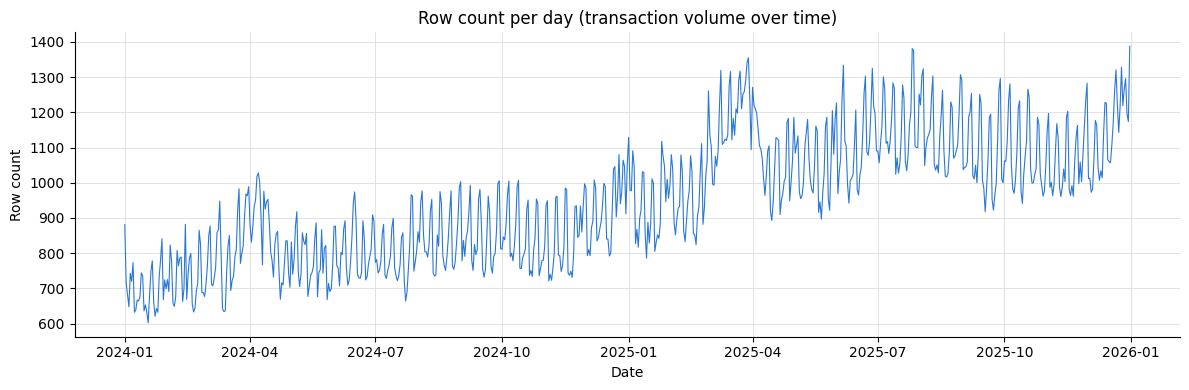

In [24]:
rows_per_day = df.groupby("Tanggal").size()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(rows_per_day.index, rows_per_day.values, color=BLUE, linewidth=0.8)
ax.set_title("Row count per day (transaction volume over time)")
ax.set_xlabel("Date")
ax.set_ylabel("Row count")
plt.tight_layout()
plt.show()

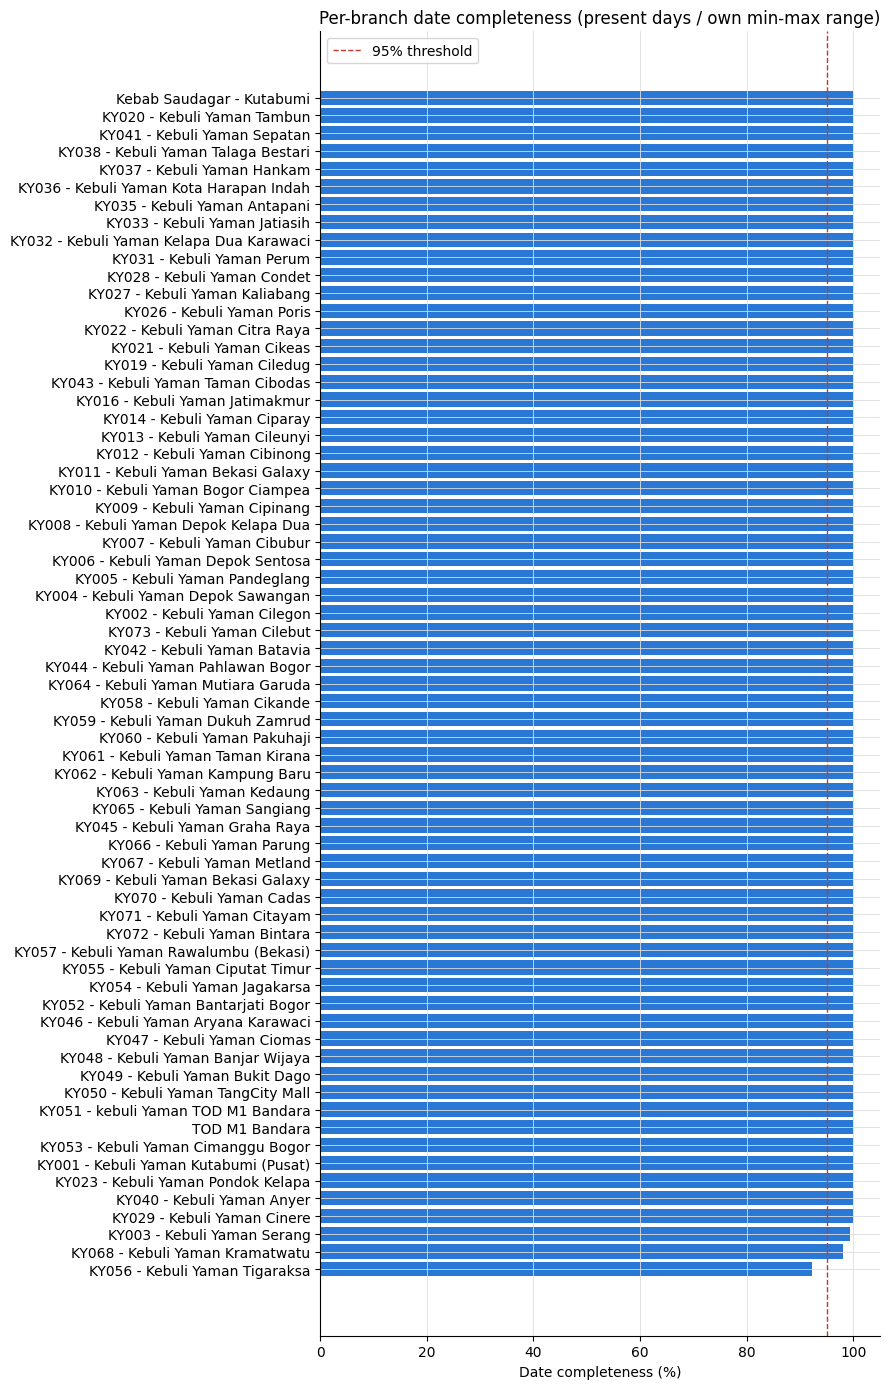

1 branches below 95% completeness:


,min,max,nunique,expected_days,completeness_pct
Nama Cabang,,,,,
KY056 - Kebuli Yaman Tigaraksa,2024-03-01,2025-12-31,619,671,92.250373


In [25]:
branch_ranges = df.groupby("Nama Cabang", observed=True)["Tanggal"].agg(["min", "max", "nunique"])
branch_ranges["expected_days"] = (branch_ranges["max"] - branch_ranges["min"]).dt.days + 1
branch_ranges["completeness_pct"] = branch_ranges["nunique"] / branch_ranges["expected_days"] * 100
branch_ranges = branch_ranges.sort_values("completeness_pct")

fig, ax = plt.subplots(figsize=(9, 14))
ax.barh(branch_ranges.index, branch_ranges["completeness_pct"], color=BLUE)
ax.axvline(95, color="#c0392b", linestyle="--", linewidth=1, label="95% threshold")
ax.set_xlabel("Date completeness (%)")
ax.set_title("Per-branch date completeness (present days / own min-max range)")
ax.legend()
plt.tight_layout()
plt.show()

below_threshold = branch_ranges[branch_ranges["completeness_pct"] < 95]
print(f"{len(below_threshold)} branches below 95% completeness:")
display(below_threshold)

## 5. Time Series & Seasonality

The day-of-week chart below is the one most directly relevant to the Region 1 (Mon/Thu) vs.
Region 2 (Tue/Fri) shipment cadence — but since no branch-to-region mapping exists yet
(see the Open Questions section), it is shown **generically** across all branches/items
combined, not split by region.

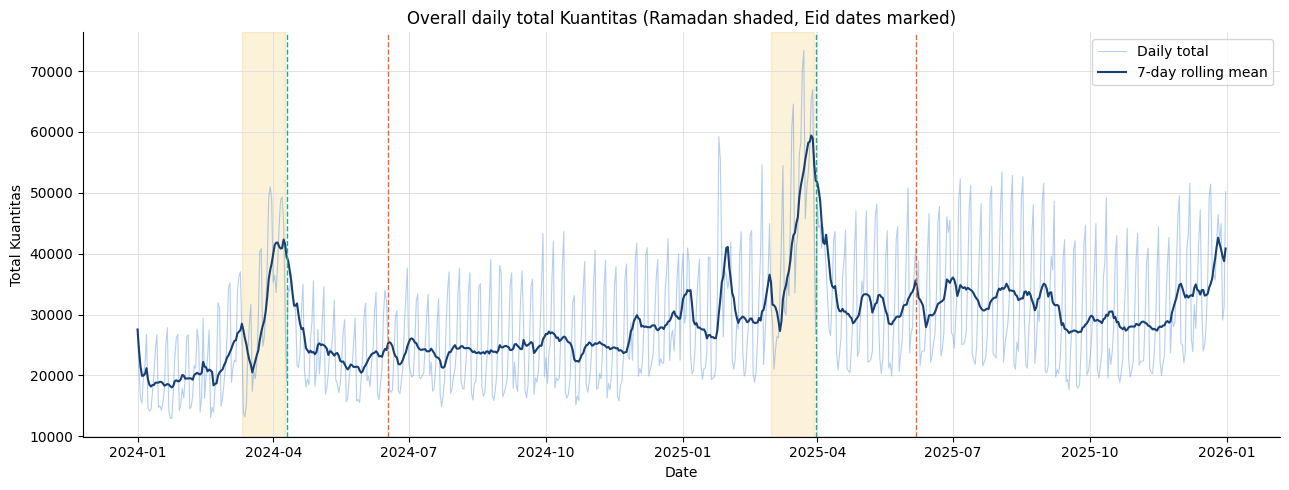

In [26]:
daily_total = df.groupby("Tanggal")["Kuantitas"].sum()
rolling_mean = daily_total.rolling(7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(daily_total.index, daily_total.values, color=BLUE, alpha=0.35, linewidth=0.8, label="Daily total")
ax.plot(rolling_mean.index, rolling_mean.values, color=BLUE_DARK, linewidth=1.5, label="7-day rolling mean")

for _, (start, end) in calendar_features.RAMADAN_PERIODS.items():
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color="#eda100", alpha=0.15)

for _, eid_date in calendar_features.EID_AL_FITR_DATES.items():
    ax.axvline(pd.Timestamp(eid_date), color="#1baf7a", linestyle="--", linewidth=1)

for _, eid_date in calendar_features.EID_AL_ADHA_DATES.items():
    ax.axvline(pd.Timestamp(eid_date), color="#eb6834", linestyle="--", linewidth=1)

ax.set_title("Overall daily total Kuantitas (Ramadan shaded, Eid dates marked)")
ax.set_xlabel("Date")
ax.set_ylabel("Total Kuantitas")
ax.legend()
plt.tight_layout()
plt.show()

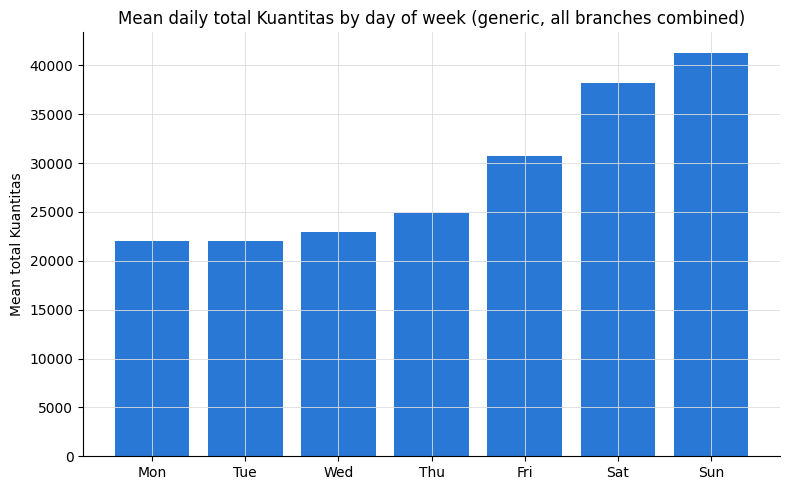

In [27]:
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
df["_dow"] = df["Tanggal"].dt.dayofweek

dow_daily_total = df.groupby(["Tanggal", "_dow"])["Kuantitas"].sum().reset_index()
dow_mean = dow_daily_total.groupby("_dow")["Kuantitas"].mean().reindex(range(7))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(dow_labels, dow_mean.values, color=BLUE)
ax.set_title("Mean daily total Kuantitas by day of week (generic, all branches combined)")
ax.set_ylabel("Mean total Kuantitas")
plt.tight_layout()
plt.show()

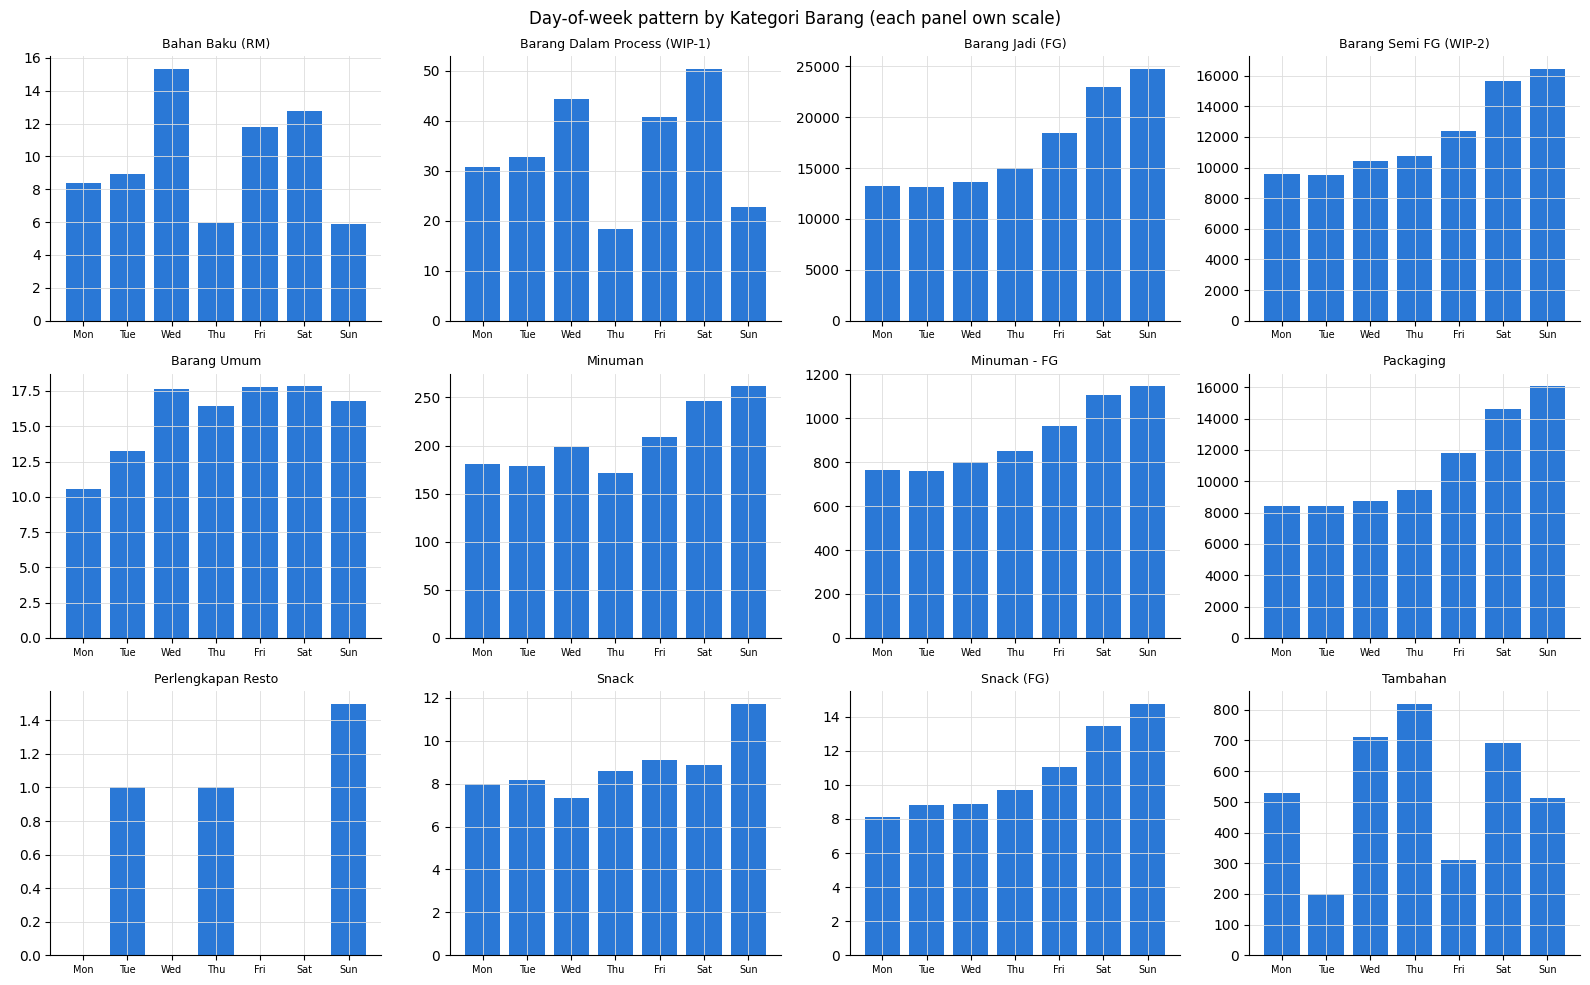

In [28]:
categories = sorted(str(c) for c in df["Kategori Barang"].unique())

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, cat in enumerate(categories):
    sub = df[df["Kategori Barang"] == cat]
    sub_daily = sub.groupby(["Tanggal", "_dow"])["Kuantitas"].sum().reset_index()
    sub_dow_mean = sub_daily.groupby("_dow")["Kuantitas"].mean().reindex(range(7)).fillna(0)
    axes[i].bar(dow_labels, sub_dow_mean.values, color=BLUE)
    axes[i].set_title(cat, fontsize=9)
    axes[i].tick_params(axis="x", labelsize=7)

for j in range(len(categories), len(axes)):
    axes[j].axis("off")

fig.suptitle("Day-of-week pattern by Kategori Barang (each panel own scale)")
plt.tight_layout()
plt.show()

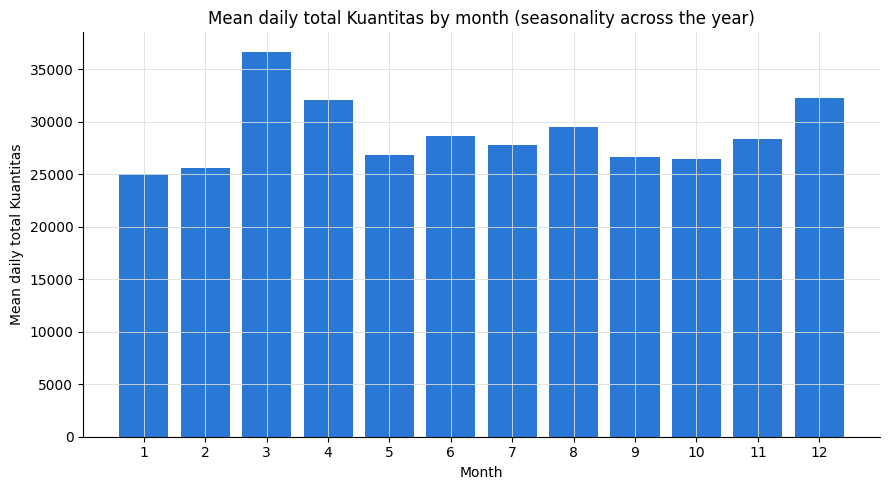

In [29]:
df["_month"] = df["Tanggal"].dt.month
monthly_total = df.groupby(["Tanggal", "_month"])["Kuantitas"].sum().reset_index()
month_mean = monthly_total.groupby("_month")["Kuantitas"].mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(month_mean.index, month_mean.values, color=BLUE)
ax.set_xticks(range(1, 13))
ax.set_xlabel("Month")
ax.set_ylabel("Mean daily total Kuantitas")
ax.set_title("Mean daily total Kuantitas by month (seasonality across the year)")
plt.tight_layout()
plt.show()

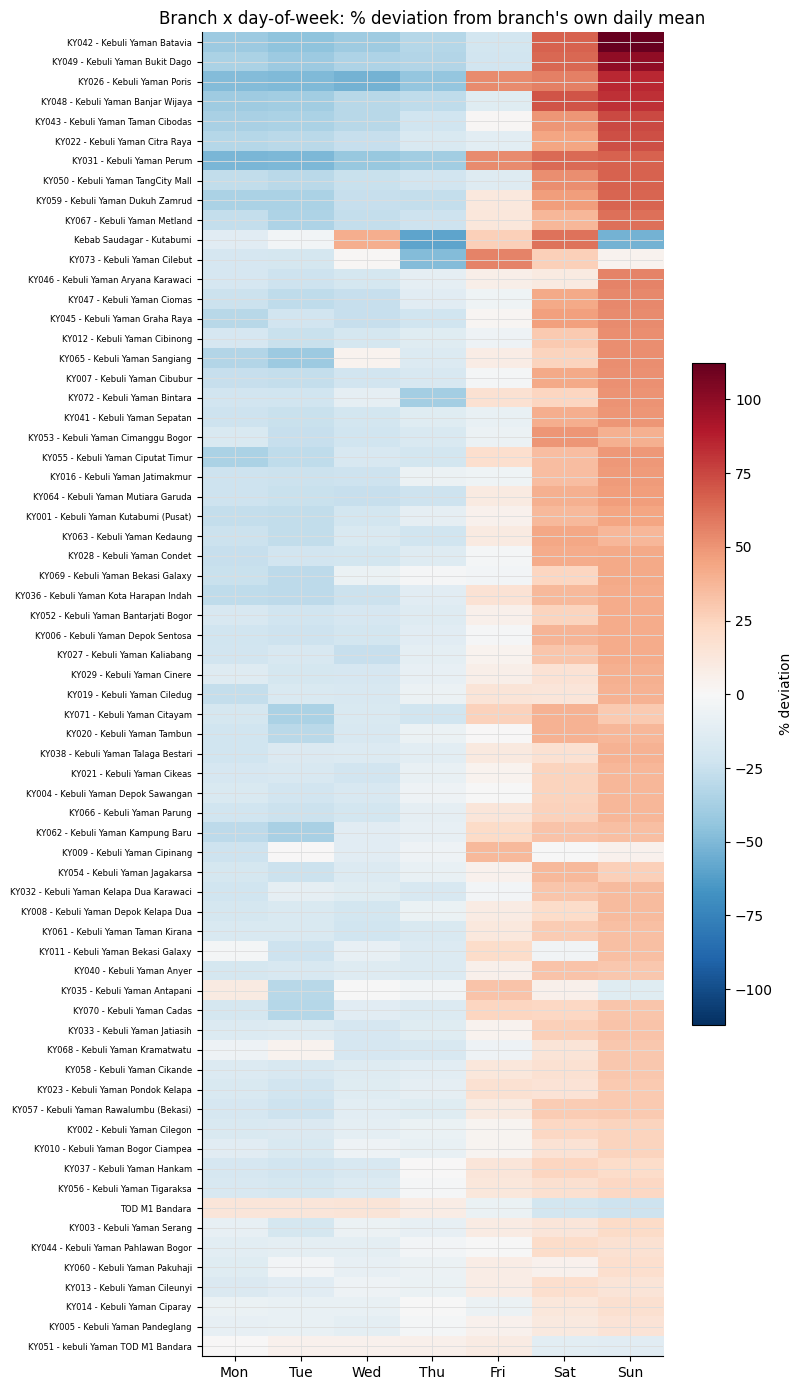

In [30]:
branch_dow = df.groupby(["Nama Cabang", "_dow"], observed=True)["Kuantitas"].sum().reset_index()
branch_dow_pivot = (
    branch_dow.pivot(index="Nama Cabang", columns="_dow", values="Kuantitas")
    .reindex(columns=range(7))
)
branch_mean = branch_dow_pivot.mean(axis=1)
branch_dow_dev = branch_dow_pivot.div(branch_mean, axis=0).sub(1).mul(100)
branch_dow_dev = branch_dow_dev.loc[branch_dow_dev.abs().max(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(8, 14))
vmax = branch_dow_dev.abs().to_numpy().max()
im = ax.imshow(branch_dow_dev.values, aspect="auto", cmap=DIVERGING_CMAP, vmin=-vmax, vmax=vmax)
ax.set_xticks(range(7))
ax.set_xticklabels(dow_labels)
ax.set_yticks(range(len(branch_dow_dev)))
ax.set_yticklabels(branch_dow_dev.index, fontsize=6)
ax.set_title("Branch x day-of-week: % deviation from branch's own daily mean")
fig.colorbar(im, ax=ax, label="% deviation", shrink=0.5)
plt.tight_layout()
plt.show()

### Year-over-year consistency check (2024 vs 2025)

The heatmap above pools both years. Before trusting per-branch day-of-week deviation as a
forecasting feature, check whether the pattern is structural (repeats every year) or just an
artifact of 2025 (e.g. new branches, a promo, a one-off event).

Cara baca: dihitung ulang deviasi per cabang secara terpisah untuk 2024 dan 2025, lalu
dikorelasikan (Pearson) bentuk kurva Mon-Sun antar dua tahun tsb per cabang. Korelasi
mendekati 1 = pola hari mingguan cabang itu konsisten tiap tahun; mendekati 0 atau negatif =
pola goyah/tidak bisa diandalkan sebagai fitur musiman-mingguan.

In [31]:
df["_year"] = df["Tanggal"].dt.year


def _branch_dow_dev(sub):
    pivot = (
        sub.groupby(["Nama Cabang", "_dow"], observed=True)["Kuantitas"]
        .sum()
        .reset_index()
        .pivot(index="Nama Cabang", columns="_dow", values="Kuantitas")
        .reindex(columns=range(7))
    )
    branch_mean = pivot.mean(axis=1)
    return pivot.div(branch_mean, axis=0).sub(1).mul(100)


dev_2024 = _branch_dow_dev(df[df["_year"] == 2024]).dropna()
dev_2025 = _branch_dow_dev(df[df["_year"] == 2025]).dropna()
common_branches = dev_2024.index.intersection(dev_2025.index)
dev_2024c, dev_2025c = dev_2024.loc[common_branches], dev_2025.loc[common_branches]

branch_corr = pd.Series(
    {
        b: np.corrcoef(dev_2024c.loc[b], dev_2025c.loc[b])[0, 1]
        for b in common_branches
        if dev_2024c.loc[b].std() > 0 and dev_2025c.loc[b].std() > 0
    }
).sort_values(ascending=False)

overall_corr = np.corrcoef(dev_2024c.values.flatten(), dev_2025c.values.flatten())[0, 1]

print(f"Branches with full 7-day coverage in both years: {len(branch_corr)}")
print(f"Mean per-branch 2024-vs-2025 correlation: {branch_corr.mean():.3f} (median {branch_corr.median():.3f})")
print(f"Branches with corr < 0.5: {(branch_corr < 0.5).sum()}")
print(f"Pooled correlation across all branch x dow cells: {overall_corr:.3f}")

print("\nMost consistent branches:")
display(branch_corr.head(5))
print("\nLeast consistent branches:")
display(branch_corr.tail(5))

Branches with full 7-day coverage in both years: 48
Mean per-branch 2024-vs-2025 correlation: 0.915 (median 0.939)
Branches with corr < 0.5: 0
Pooled correlation across all branch x dow cells: 0.929

Most consistent branches:


KY042 - Kebuli Yaman Batavia             0.998131
KY012 - Kebuli Yaman Cibinong            0.995002
KY001 - Kebuli Yaman Kutabumi (Pusat)    0.994714
KY050 - Kebuli Yaman TangCity Mall       0.993041
KY031 - Kebuli Yaman Perum               0.990841
dtype: float64


Least consistent branches:


KY002 - Kebuli Yaman Cilegon               0.799559
KY036 - Kebuli Yaman Kota Harapan Indah    0.794148
KY044 - Kebuli Yaman Pahlawan Bogor        0.787201
KY005 - Kebuli Yaman Pandeglang            0.786969
KY057 - Kebuli Yaman Rawalumbu (Bekasi)    0.638799
dtype: float64

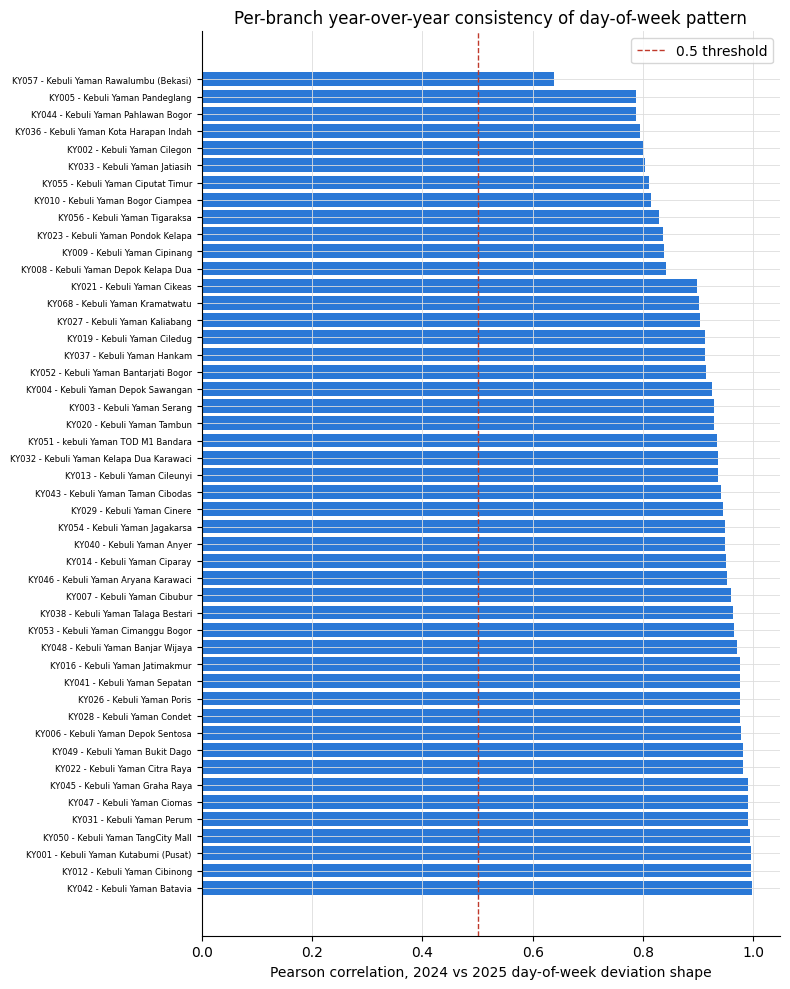

In [32]:
fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(branch_corr.index, branch_corr.values, color=BLUE)
ax.axvline(0.5, color="#c0392b", linestyle="--", linewidth=1, label="0.5 threshold")
ax.set_xlabel("Pearson correlation, 2024 vs 2025 day-of-week deviation shape")
ax.set_title("Per-branch year-over-year consistency of day-of-week pattern")
ax.tick_params(axis="y", labelsize=6)
ax.legend()
plt.tight_layout()
plt.show()

## 6. Item x Outlet Structure

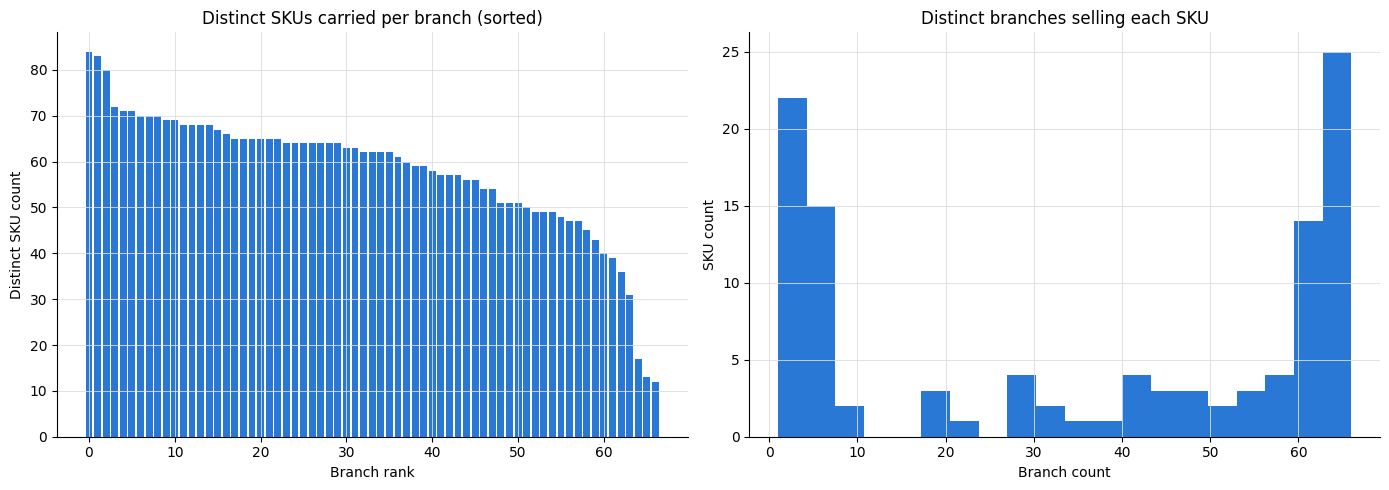

In [33]:
sku_per_branch = df.groupby("Nama Cabang", observed=True)["Kode Barang"].nunique().sort_values(ascending=False)
branch_per_sku = df.groupby("Kode Barang")["Nama Cabang"].nunique()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(len(sku_per_branch)), sku_per_branch.values, color=BLUE)
axes[0].set_title("Distinct SKUs carried per branch (sorted)")
axes[0].set_xlabel("Branch rank")
axes[0].set_ylabel("Distinct SKU count")

axes[1].hist(branch_per_sku.values, bins=20, color=BLUE)
axes[1].set_title("Distinct branches selling each SKU")
axes[1].set_xlabel("Branch count")
axes[1].set_ylabel("SKU count")

plt.tight_layout()
plt.show()

/Users/ramapdp/Project/Personal/forecast-scm/utils/data_preprocessing/build_panel.py:111: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for keys, group in df.groupby(pair_cols):


Dense panel shape: (1516114, 8)


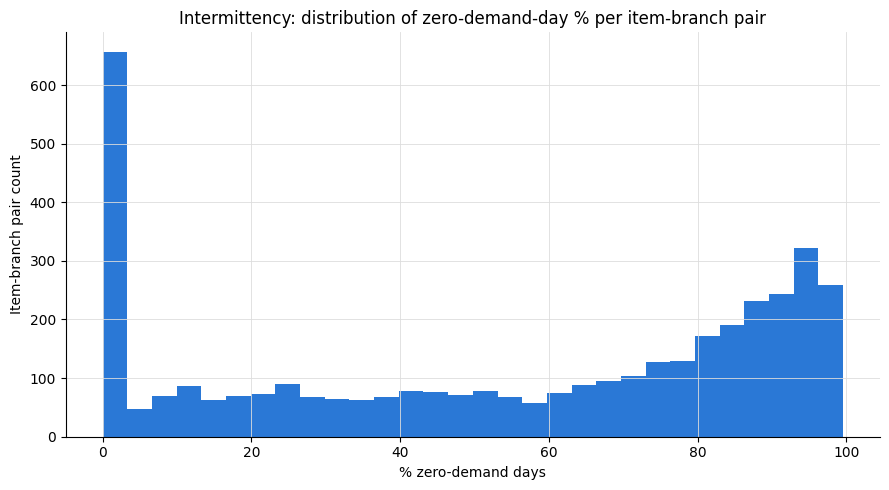

Median zero-demand %: 64.0%
Share of pairs with >50% zero-demand days: 57.1%


In [34]:
panel = build_panel.build_dense_panel(df)
print(f"Dense panel shape: {panel.shape}")

zero_pct = (
    panel.assign(is_zero=panel["Kuantitas"] == 0)
    .groupby(["Kode Barang", "Nama Cabang"], observed=True)["is_zero"]
    .mean()
    .mul(100)
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(zero_pct.values, bins=30, color=BLUE)
ax.set_xlabel("% zero-demand days")
ax.set_ylabel("Item-branch pair count")
ax.set_title("Intermittency: distribution of zero-demand-day % per item-branch pair")
plt.tight_layout()
plt.show()

print(f"Median zero-demand %: {zero_pct.median():.1f}%")
print(f"Share of pairs with >50% zero-demand days: {(zero_pct > 50).mean() * 100:.1f}%")

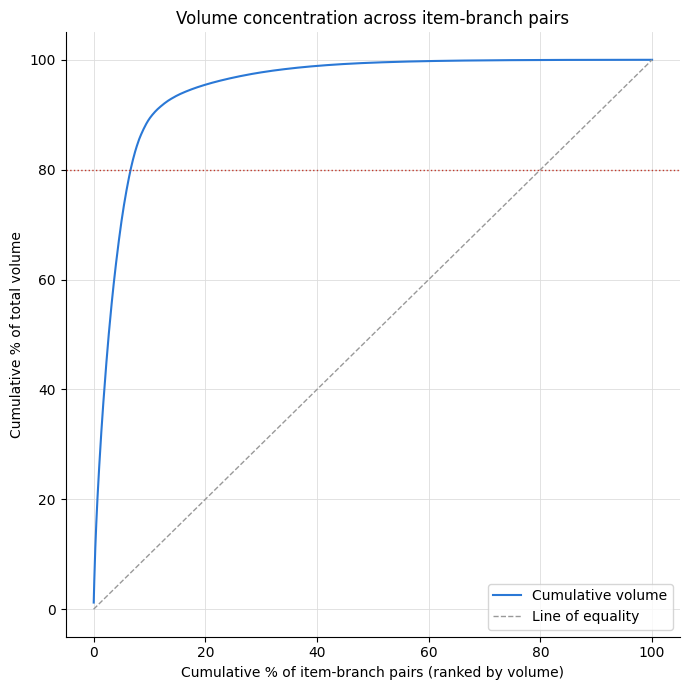

Top 6.6% of item-branch pairs account for 80% of total volume


In [35]:
pair_volume = (
    df.groupby(["Kode Barang", "Nama Cabang"], observed=True)["Kuantitas"]
    .sum()
    .sort_values(ascending=False)
)
cum_volume_pct = (pair_volume.cumsum() / pair_volume.sum() * 100).values
cum_pairs_pct = np.arange(1, len(pair_volume) + 1) / len(pair_volume) * 100

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(cum_pairs_pct, cum_volume_pct, color=BLUE, linewidth=1.5, label="Cumulative volume")
ax.plot([0, 100], [0, 100], color="#999999", linestyle="--", linewidth=1, label="Line of equality")
ax.axhline(80, color="#c0392b", linestyle=":", linewidth=1)
ax.set_xlabel("Cumulative % of item-branch pairs (ranked by volume)")
ax.set_ylabel("Cumulative % of total volume")
ax.set_title("Volume concentration across item-branch pairs")
ax.legend()
plt.tight_layout()
plt.show()

idx_80 = int(np.searchsorted(cum_volume_pct, 80))
print(f"Top {cum_pairs_pct[idx_80]:.1f}% of item-branch pairs account for 80% of total volume")

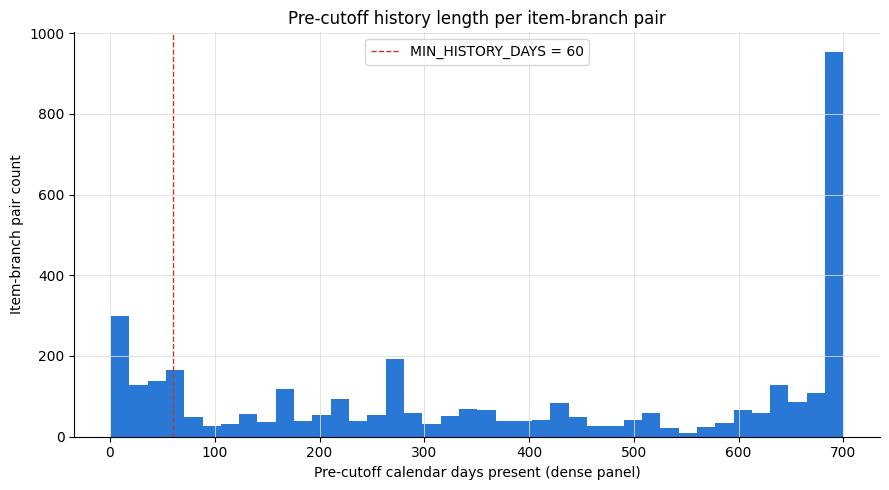

3040/3882 pairs (78.3%) meet the 60-day minimum-history threshold used downstream (build_panel.filter_min_history)


In [36]:
filtered = build_panel.filter_min_history(panel)
n_total_pairs = panel[["Kode Barang", "Nama Cabang"]].drop_duplicates().shape[0]
n_passing_pairs = filtered[["Kode Barang", "Nama Cabang"]].drop_duplicates().shape[0]

pre_cutoff_panel = panel[panel["Tanggal"] < build_panel.TEST_START]
history_days = pre_cutoff_panel.groupby(["Kode Barang", "Nama Cabang"], observed=True).size()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(history_days.values, bins=40, color=BLUE)
ax.axvline(
    build_panel.MIN_HISTORY_DAYS, color="#c0392b", linestyle="--", linewidth=1,
    label=f"MIN_HISTORY_DAYS = {build_panel.MIN_HISTORY_DAYS}",
)
ax.set_xlabel("Pre-cutoff calendar days present (dense panel)")
ax.set_ylabel("Item-branch pair count")
ax.set_title("Pre-cutoff history length per item-branch pair")
ax.legend()
plt.tight_layout()
plt.show()

print(
    f"{n_passing_pairs}/{n_total_pairs} pairs ({n_passing_pairs / n_total_pairs * 100:.1f}%) "
    f"meet the {build_panel.MIN_HISTORY_DAYS}-day minimum-history threshold used downstream "
    "(build_panel.filter_min_history)"
)

## 7. Lead-Time Proxy Analysis

Generic (non-region-segmented) rolling 3-day and 4-day trailing cumulative-demand windows,
as a proxy for "demand until next shipment" under the Region 1 (3- or 4-day gap depending on
Mon vs. Thu shipment) / Region 2 (3- or 4-day gap depending on Tue vs. Fri shipment) cadence.
**These windows are deliberately not anchored to any guessed region/day assignment** — that
would require the Region 1/2 mapping this notebook explicitly does not have (see Open
Questions).

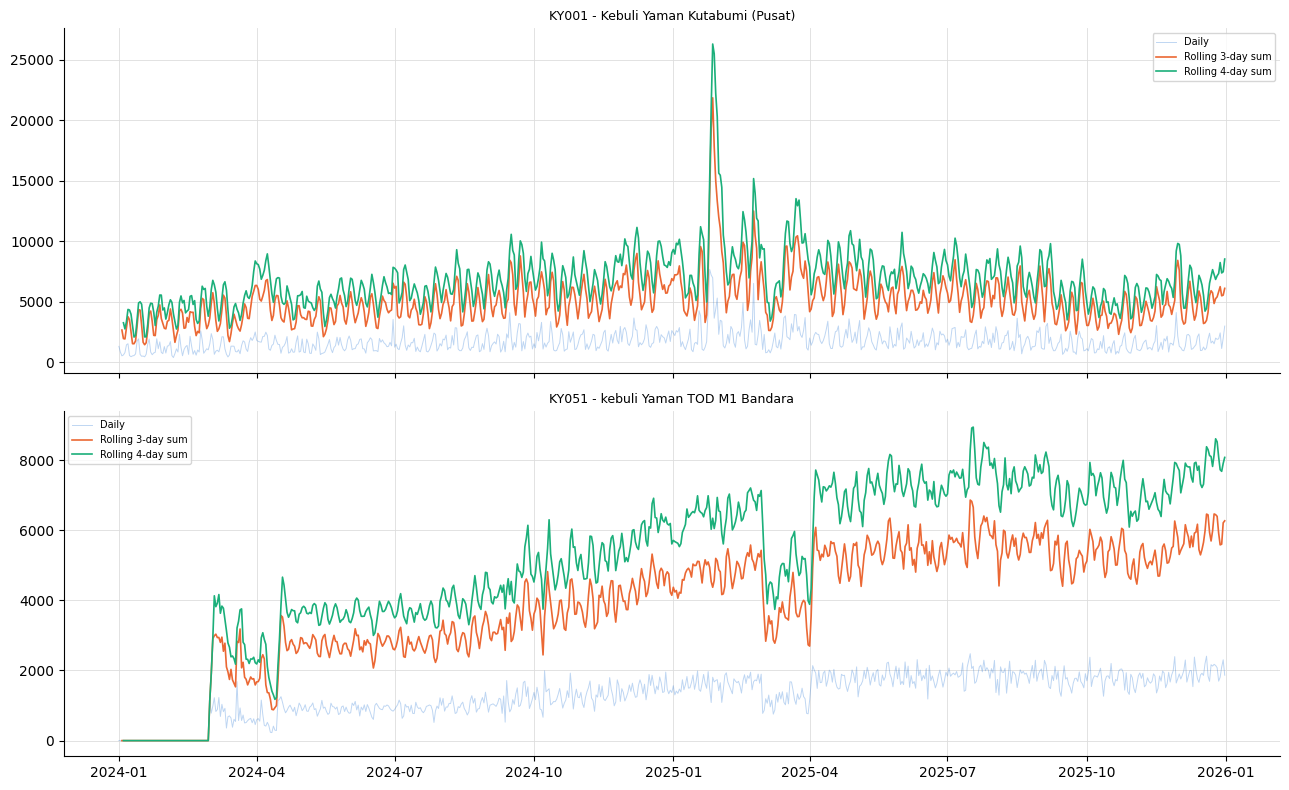

In [37]:
full_range = pd.date_range(df["Tanggal"].min(), df["Tanggal"].max(), freq="D")
branch_daily_pivot = (
    df.pivot_table(index="Tanggal", columns="Nama Cabang", values="Kuantitas", aggfunc="sum", observed=True)
    .reindex(full_range)
    .fillna(0)
)

roll_3 = branch_daily_pivot.rolling(3).sum()
roll_4 = branch_daily_pivot.rolling(4).sum()

top2_branches = (
    df.groupby("Nama Cabang", observed=True)["Kuantitas"].sum().sort_values(ascending=False).head(2).index.tolist()
)

fig, axes = plt.subplots(len(top2_branches), 1, figsize=(13, 8), sharex=True)
for ax, branch in zip(axes, top2_branches):
    ax.plot(branch_daily_pivot.index, branch_daily_pivot[branch], color=BLUE, alpha=0.3, linewidth=0.7, label="Daily")
    ax.plot(roll_3.index, roll_3[branch], color=CATEGORICAL[1], linewidth=1.2, label="Rolling 3-day sum")
    ax.plot(roll_4.index, roll_4[branch], color=CATEGORICAL[2], linewidth=1.2, label="Rolling 4-day sum")
    ax.set_title(branch, fontsize=9)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

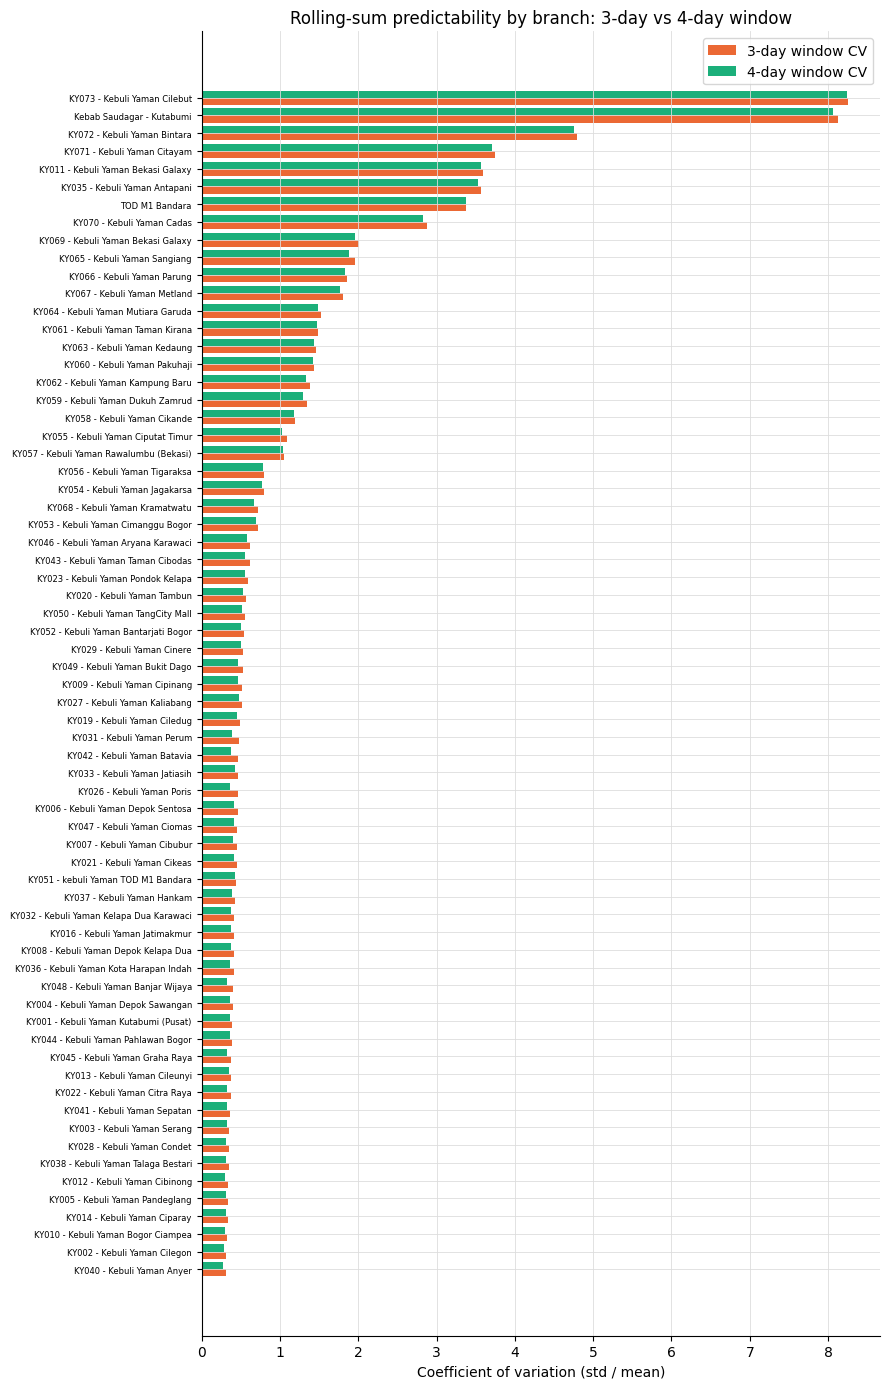

In [38]:
cv_3 = roll_3.std() / roll_3.mean()
cv_4 = roll_4.std() / roll_4.mean()
cv_compare = pd.DataFrame({"cv_3day": cv_3, "cv_4day": cv_4}).sort_values("cv_3day")

fig, ax = plt.subplots(figsize=(9, 14))
y = np.arange(len(cv_compare))
ax.barh(y - 0.2, cv_compare["cv_3day"], height=0.4, color=CATEGORICAL[1], label="3-day window CV")
ax.barh(y + 0.2, cv_compare["cv_4day"], height=0.4, color=CATEGORICAL[2], label="4-day window CV")
ax.set_yticks(y)
ax.set_yticklabels(cv_compare.index, fontsize=6)
ax.set_xlabel("Coefficient of variation (std / mean)")
ax.set_title("Rolling-sum predictability by branch: 3-day vs 4-day window")
ax.legend()
plt.tight_layout()
plt.show()

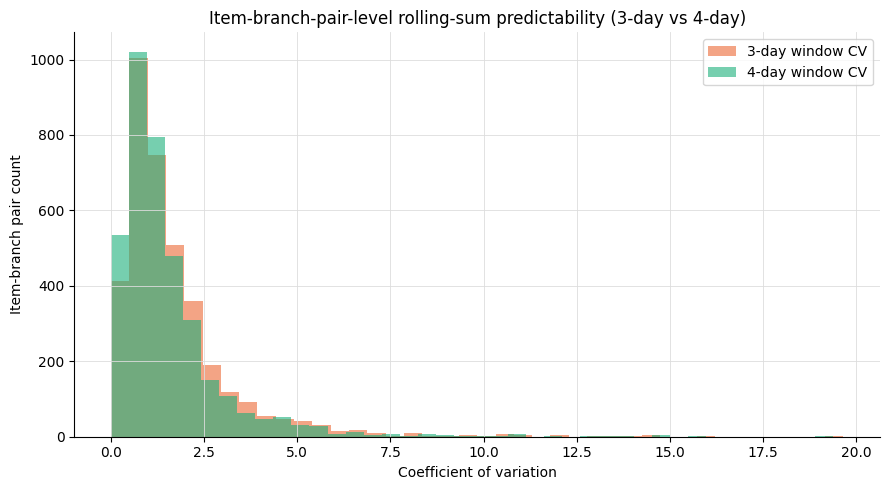

,cv_3,cv_4
count,3707.000000,3696.000000
mean,1.729366,1.559617
std,1.682734,1.593688
min,0.000000,0.000000
25%,0.756249,0.676397
50%,1.251207,1.118254
75%,2.086658,1.849979
max,19.658069,19.371721


In [39]:
panel_sorted = panel.sort_values(["Kode Barang", "Nama Cabang", "Tanggal"])
grp = panel_sorted.groupby(["Kode Barang", "Nama Cabang"], observed=True)["Kuantitas"]
panel_sorted["roll_3"] = grp.transform(lambda s: s.rolling(3).sum())
panel_sorted["roll_4"] = grp.transform(lambda s: s.rolling(4).sum())

pair_cv = panel_sorted.groupby(["Kode Barang", "Nama Cabang"], observed=True).agg(
    cv_3=("roll_3", lambda s: s.std() / s.mean() if s.mean() else np.nan),
    cv_4=("roll_4", lambda s: s.std() / s.mean() if s.mean() else np.nan),
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(pair_cv["cv_3"].dropna(), bins=40, alpha=0.6, color=CATEGORICAL[1], label="3-day window CV")
ax.hist(pair_cv["cv_4"].dropna(), bins=40, alpha=0.6, color=CATEGORICAL[2], label="4-day window CV")
ax.set_xlabel("Coefficient of variation")
ax.set_ylabel("Item-branch pair count")
ax.set_title("Item-branch-pair-level rolling-sum predictability (3-day vs 4-day)")
ax.legend()
plt.tight_layout()
plt.show()

pair_cv.describe()

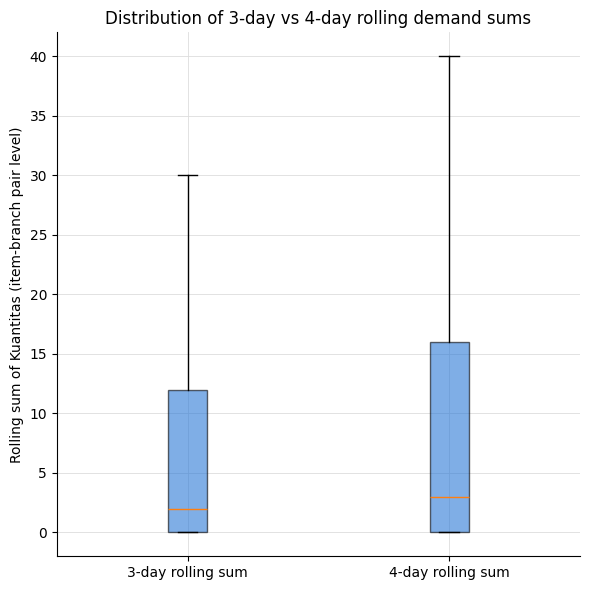

In [40]:
fig, ax = plt.subplots(figsize=(6, 6))
box = ax.boxplot(
    [panel_sorted["roll_3"].dropna(), panel_sorted["roll_4"].dropna()],
    tick_labels=["3-day rolling sum", "4-day rolling sum"],
    patch_artist=True,
    showfliers=False,
)
for patch in box["boxes"]:
    patch.set_facecolor(BLUE)
    patch.set_alpha(0.6)
ax.set_ylabel("Rolling sum of Kuantitas (item-branch pair level)")
ax.set_title("Distribution of 3-day vs 4-day rolling demand sums")
plt.tight_layout()
plt.show()

## 8. Open Questions / Data Gaps

In [41]:
outlets_df = outlet_features.load_outlets()
print("dataset/outlets.csv columns:")
print(list(outlets_df.columns))

negative_count = int((df["Kuantitas"] < 0).sum())
if negative_count == 0:
    print("OK: no negative Kuantitas values found in dataset.csv (soft check, not an assertion).")
else:
    print(
        f"NOTE: found {negative_count} negative Kuantitas rows — see CLAUDE.md for the known "
        "KY011 2024-02-29 anomaly context."
    )

dataset/outlets.csv columns:
['Nama Outlet', 'Alamat', 'Kecamatan', 'Kota', 'has_shopee', 'has_gofood', 'has_grabfood']
OK: no negative Kuantitas values found in dataset.csv (soft check, not an assertion).


## 9. Conclusion & Pre-Modeling Verification Checklist

One row per finding: the conclusion from this EDA pass, and — if anything — what still needs
a data-owner/SCM decision before this dataset feeds `normalize_items.py` / `build_panel.py` /
`prepare_forecast_data.py`.

| # | Finding / Conclusion | Verify before modeling |
|---|---|---|
| 1 | Data quality is clean: 693,563 rows, 2024-01-01–2025-12-31, 0 missing values, 0 duplicates. | None — ready as-is. |
| 2 | `Kuantitas` is heavily right-skewed (median 5, mean ~30.4, max 5,250) and, as of the 2026-08-06 source refresh, genuinely fractional (dtype float64, e.g. `5.8`, `92.5`) rather than integer-only — confirmed intentional by the data owner, not an export artifact. | Eyeball the top-20 outlier rows (§3) for unit-multiplier / data-entry errors before treating them as genuine bulk orders. Make sure downstream preprocessing/model code treats Kuantitas as continuous, not integer-count. |
| 3 | Branch date-completeness is strong: 66/67 branches ≥95%; only KY056 (Kebuli Yaman Tigaraksa) is below, at 92.3%. | Ask data owner whether KY056's gap is a reporting gap, a temporary closure, or a newer outlet. |
| 4 | Demand is highly intermittent at the item-branch-pair level (median 64% zero-demand days; 57.1% of pairs >50% zero). | None — this is a modeling-method decision (avoid pure ARIMA-style continuous-demand assumptions), not a data question. |
| 5 | Volume is concentrated: the top 6.6% of item-branch pairs drive 80% of total volume. | None — informs evaluation weighting, not a data question. |
| 6 | 78.3% of item-branch pairs (3,040/3,882) clear the existing 60-day `MIN_HISTORY_DAYS` threshold; ~22% would be dropped under current rules. | Data owner to review the failing pairs — new SKU, new outlet, or reporting gap? — before deciding to drop them or relax the threshold. |
| 7 | `xxx.`-prefixed items can't always be auto-merged into their non-prefixed counterpart — e.g. `xxx.FGS.00069` "Cendol Pandan" vs `FGS`-coded "Cendol" have different names, so normalization can't assume they're the same SKU. | Data owner decision required: drop, keep as a separate SKU, or manually confirm the merge. |
| 8 | No negative `Kuantitas` rows found in the current `dataset/dataset.csv` — the known KY011 2024-02-29 anomaly is resolved in this run, using the current `dataset/csv/feb-24.csv` (already comma-decimal formatted, consistent with the other four source months). | Not yet permanently confirmed by the data owner — rerun this check every time `dataset.csv` is regenerated. |
| 9 | **(New check)** Every `Kode Barang` maps to exactly one `Satuan` — 0/109 SKUs have more than one unit of measure. | None — confirmed consistent, safe to aggregate `Kuantitas` per SKU. |
| 10 | **(New check)** 27/109 SKUs (24.8%) appear under more than one `Kategori Barang` over time — e.g. `Minuman` → `Minuman - FG`, `Barang Semi FG (WIP-2)` → `Barang Jadi (FG)`, `Snack` → `Snack (FG)`. The consistent pairing pattern looks like a mid-2024 category-taxonomy rename rather than random data-entry noise. | Confirm with the data owner whether this is an intentional taxonomy rename, and if so decide whether `normalize_items.py` should use each SKU's most-recent category (current pipeline assumes one fixed category per SKU) or treat category as time-varying. |
| 11 | No Region 1 (Mon/Thu) / Region 2 (Tue/Fri) delivery-schedule mapping exists in `dataset/outlets.csv` — it only has `Kecamatan`/`Kota`. This blocks region-segmented versions of the day-of-week (§5) and lead-time-window (§7) analyses, which are generic proxies only. | Ask the SCM team for a branch → region (or branch → delivery-day) column on `dataset/outlets.csv`, joined the same way `outlet_features.py` already joins `has_shopee`/`has_gofood`/`has_grabfood`. |
| 12 | Lead-time proxy: a 4-day rolling window is mildly more predictable than a 3-day window (median CV ~1.12 vs ~1.25). | This is a generic, non-region-segmented proxy — don't finalize until #11's region mapping lands. |
| 13 | Clear weekly and Ramadan/Eid-linked seasonality exist overall and per category (§5). | Confirm `calendar_features.py`'s `RAMADAN_PERIODS`/`EID_AL_FITR_DATES`/`EID_AL_ADHA_DATES` fully cover 2024-2025 via `check_year_coverage`. |

**Priority order:** rows 7, 10, and 11 are the biggest blockers — each can silently distort
`normalize_items.py` or `build_panel.py` output if skipped, and none can be resolved from the
data alone.